In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 타이타닉 데이터셋 컬럼 명세 (Metadata)

| 컬럼명 | 데이터 타입 | 설명 및 주요 값 예시 |
| :--- | :---: | :--- |
| **PassengerId** | `int64` | 승객 고유 번호 (1, 2, 3...) |
| **Survived** | `int64` | 생존 여부 (**0**: 사망 / **1**: 생존) |
| **Pclass** | `int64` | 객실 등급 (**1**: 1등석, **2**: 2등석, **3**: 3등석) |
| **Name** | `object` | 승객 이름 (호칭 포함: Mr, Mrs, Miss 등) |
| **Sex** | `object` | 성별 (`male`: 남성 / `female`: 여성) |
| **Age** | `float64` | 승객 나이 (결측치 존재) |
| **SibSp** | `int64` | 함께 탑승한 형제자매/배우자 수 (Siblings / Spouses) |
| **Parch** | `int64` | 함께 탑승한 부모/자녀 수 (Parents / Children) |
| **Ticket** | `object` | 티켓 번호 |
| **Fare** | `float64` | 탑승 요금 |
| **Cabin** | `object` | 객실 번호 (결측치 다수 존재) |
| **Embarked** | `object` | 탑승 항구 (**C**: Cherbourg, **Q**: Queenstown, **S**: Southampton) |

In [2]:
import os
import pandas as pd

base_path = "/Users/hyusoohi5/kdt_0900_khs/ml/resource/"
file_name = "titanic.csv"

file_path = os.path.join(base_path, file_name)

print(file_path)
print(os.path.exists(file_path))

df = pd.read_csv(file_path)

df.head()

/Users/hyusoohi5/kdt_0900_khs/ml/resource/titanic.csv
True


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
drop_columns = ["PassengerId", "Name", "Ticket", "Cabin", "Embarked"]
titanic_df = df.drop(drop_columns, axis=1)

In [4]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB


In [5]:
titanic_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# 수치형 데이터 : Age, SibSp, Parch, Fare
# 분류형 데이터 : Survived, Pclass, Sex

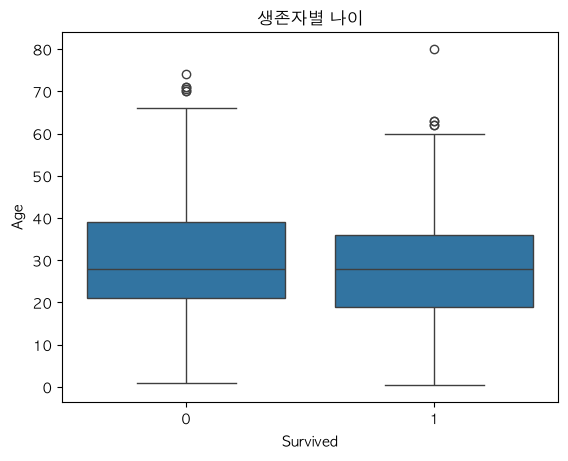

In [7]:
# 생존자별 나이
sns.boxplot(titanic_df, x="Survived", y="Age")
plt.title("생존자별 나이")

plt.show()

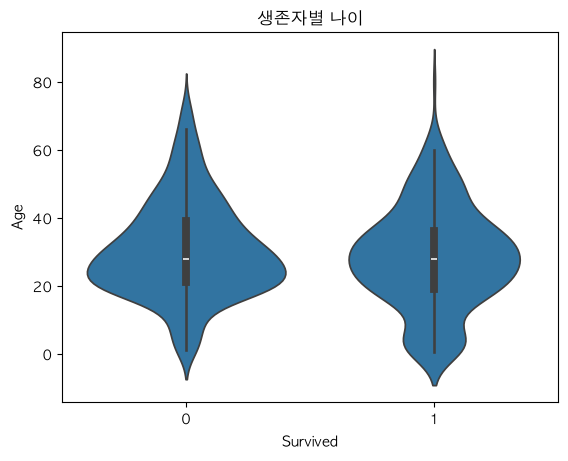

In [8]:
# 생존자별 나이
sns.violinplot(titanic_df, x="Survived", y="Age")
plt.title("생존자별 나이")

plt.show()

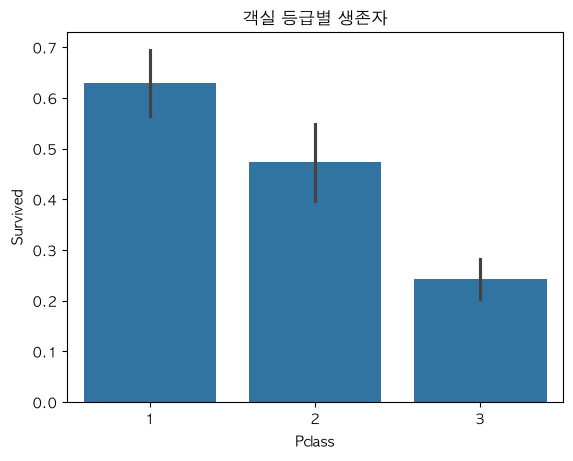

In [9]:
sns.barplot(titanic_df, x="Pclass", y="Survived")
plt.title("객실 등급별 생존자")

plt.show()

In [10]:
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Age"] = titanic_df["Age"].astype(int)
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    int64  
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 48.9 KB


### 원 핫 인코딩(one-hot-encoding)
- 글자나, 범주형 데이터를 컴퓨터가 좋아하는 0과 1의 행렬구조로 변환하는 전처리 기술

In [11]:
titanic_df["Sex"] = titanic_df["Sex"].map(lambda gender: {"male" : 0, "female" : 1}[gender])

In [12]:
titanic_df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22,1,0,7.2500
1,1,1,1,38,1,0,71.2833
2,1,3,1,26,0,0,7.9250


### 파생 변수

In [13]:
titanic_df["FamilySize"] = titanic_df["SibSp"] + titanic_df["Parch"] + 1
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,0,3,0,22,1,0,7.2500,2
1,1,1,1,38,1,0,71.2833,2
2,1,3,1,26,0,0,7.9250,1
3,1,1,1,35,1,0,53.1000,2
4,0,3,0,35,0,0,8.0500,1


### ⭐️ 상관관계 분석 및 다중공선성

In [14]:
corr_matrix = titanic_df.corr(numeric_only=True)
corr_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
Survived,1.000000,-0.338481,0.543351,-0.064909,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.131900,-0.339999,0.083081,0.018443,-0.549500,0.065997
Sex,0.543351,-0.131900,1.000000,-0.080750,0.114631,0.245489,0.182333,0.200988
Age,-0.064909,-0.339999,-0.080750,1.000000,-0.233066,-0.172745,0.096838,-0.245593
SibSp,-0.035322,0.083081,0.114631,-0.233066,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,0.245489,-0.172745,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.182333,0.096838,0.159651,0.216225,1.000000,0.217138
FamilySize,0.016639,0.065997,0.200988,-0.245593,0.890712,0.783111,0.217138,1.000000


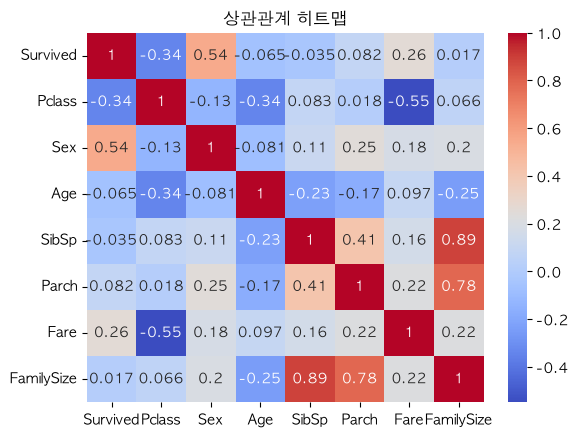

In [15]:
# 음의 상관관계일 때 cool, 양일 때 warm
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("상관관계 히트맵")

plt.show()

### VIF
- 한 독립변수가 다른 독립변수들에 의해 얼마나 잘 설명되는지 설명하는 값을 의미한다.
- 즉, 독립변수와 독립변수와의 관계를 의미하며 다른 변수들과의 조합을 수치로 표현한 것이다.

### VIF 해석
- VIF < 5: 문제 없음
- <= VIF <= 10 : 주의
- VIF > 10 : 다중 공선성 의심(조치, 삭제, 고려)

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [17]:
X = titanic_df.drop("Survived", axis=1)
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
0,3,0,22,1,0,7.2500,2
1,1,1,38,1,0,71.2833,2
2,3,1,26,0,0,7.9250,1
3,1,1,35,1,0,53.1000,2
4,3,0,35,0,0,8.0500,1


In [18]:
y = titanic_df["Survived"]
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [36]:
X = X.drop(columns=["SibSp", "Parch"])

vif = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

In [38]:
print(X.columns)

Index(['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize'], dtype='str')


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=2026
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 7) (179, 7) (712,) (179,)


In [21]:
# 표준화 과정
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2단계, 모델 준비

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
lr = LogisticRegression()

## 3단계, 모델 학습

In [24]:
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

## 4단계, 모델 평가

In [25]:
train_score = lr.score(X_train_scaled, y_train)
test_score = lr.score(X_test_scaled, y_test)

print(f"훈련 데이터 점수 : {train_score}")
print(f"테스트 데이터 점수 : {test_score}")

훈련 데이터 점수 : 0.797752808988764
테스트 데이터 점수 : 0.7821229050279329


### 시그모이드 함수 (Sigmoid Function)
수학자들이 만든 특수한 함수로, 여기에 어떤 숫자를 넣든 무조건 **0과 1 사이의 소수점(확률)**으로 꽉 눌러서 변환해 줍니다.

$$\text{Sigmoid}(z) = \frac{1}{1 + e^{-z}}$$

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fsib2q%2FbtsDJkfaBMy%2FAAAAAAAAAAAAAAAAAAAAAJwQd20TZhIxLx58GiUJdYxCLH_4xkSt66vEea-TnEkx%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DZyqh5kd4SOqkuF96VWHHU3%252B91F0%253D)

In [26]:
y_pred = lr.predict(X_test_scaled)

print(f"모델의 예측 확률 : {lr.predict_proba(X_test_scaled)[:5]}")
print(f"모델의 예측 값 : {y_pred[:5]}")
print(f"모델의 정답 : {y_test.values[:5]}")

모델의 예측 확률 : [[0.88924204 0.11075796]
 [0.9522437  0.0477563 ]
 [0.04827506 0.95172494]
 [0.88548969 0.11451031]
 [0.89910014 0.10089986]]
모델의 예측 값 : [0 0 1 0 0]
모델의 정답 : [0 0 1 0 0]


In [27]:
print(f"테스트 정확도 : {lr.score(X_train_scaled, y_train)}")
print(f"테스트 정확도 : {accuracy_score(y_pred=y_pred, y_true=y_test)}")

테스트 정확도 : 0.797752808988764
테스트 정확도 : 0.7821229050279329


In [28]:
X_train.head(1)

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
413,2,0,28,0,0,0.0,1


In [29]:
from sklearn.metrics import RocCurveDisplay

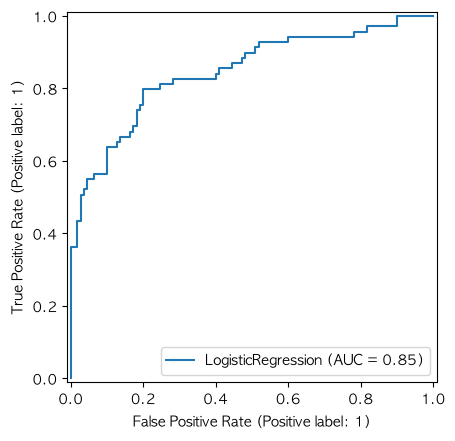

In [30]:
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)

In [31]:
coef_df = pd.DataFrame({
    "Features" : X_train.columns,
    "Coef" : lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
1,Sex,1.327947
5,Fare,0.148105
4,Parch,-0.027450
6,FamilySize,-0.137963
3,SibSp,-0.183809
2,Age,-0.511181
0,Pclass,-0.913418


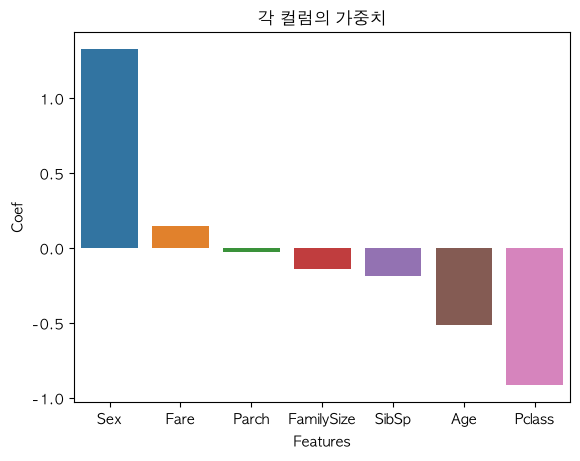

'\n    성별은 양의 상관관계를 가진다. 즉 성별이 1(female)일수록 생존 확률이 높다.(1)\n    객실 등급(Pclass)는 음의 상관관계를 가진다. 즉, 객실 등급 값이 낮을수록(1) 생존확률이 높다.(1)\n'

In [32]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features")
plt.title("각 컬럼의 가중치")

plt.show()

"""
    성별은 양의 상관관계를 가진다. 즉 성별이 1(female)일수록 생존 확률이 높다.(1)
    객실 등급(Pclass)는 음의 상관관계를 가진다. 즉, 객실 등급 값이 낮을수록(1) 생존확률이 높다.(1)
"""

In [33]:
# 모델이 틀리게 예측한 행
wrong_cases = X_test[y_test != y_pred]
wrong_cases.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
400,3,0,39,0,0,7.9250,1
593,3,1,28,0,2,7.7500,3
630,1,0,80,0,0,30.0000,1
569,3,0,32,0,0,7.8542,1
271,3,0,25,0,0,0.0000,1


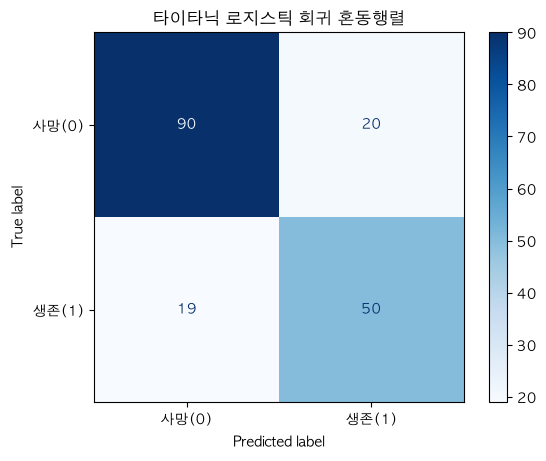

In [34]:
ConfusionMatrixDisplay.from_estimator(
    lr, X_test_scaled, y_test, display_labels=["사망(0)", "생존(1)"], cmap="Blues")

plt.title("타이타닉 로지스틱 회귀 혼동행렬")
plt.show()

In [35]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82       109
           1       0.72      0.71      0.72        70

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

